In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import haiku as hk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probjax.nn.loss_fn import high_order_denosing_score_matching_loss

In [29]:
d = 1

def model(t, x):
    x = x
    h = hk.Sequential([
        hk.Linear(50), jax.nn.gelu,
        hk.Linear(50), jax.nn.gelu,
        hk.Linear(50), jax.nn.gelu,
    ])(x)
    h2 = hk.Sequential([
        hk.Linear(50), jax.nn.gelu,
        hk.Linear(50), jax.nn.gelu,
        hk.Linear(50), jax.nn.gelu,
    ])(x)
    out = hk.Linear(d)(h)
    jac_out_diag = hk.Linear(d)(h2)
    jac_out_diag = jax.nn.gelu(jac_out_diag)
    jac_out_diag = hk.Linear(d)(jac_out_diag)
    if d > 1:
        jac_non_diag = hk.Linear(d*d)(h2)
        jac_non_diag = jnp.reshape(jac_non_diag, (-1, d, d))
        jac_non_diag = jnp.einsum('...ij, ...jk -> ...ik', jac_non_diag, jac_non_diag)
        jac = jnp.diag(jac_out_diag) + jac_non_diag
    else:
        jac = jac_out_diag

    return out, jac



init_fn, model_fn = hk.without_apply_rng(hk.transform(model))

key = jax.random.PRNGKey(0)
x = jax.random.normal(key, (10,d))
times = jnp.array([0.])


mu1 = -2.0 * jnp.ones((d,))
mu2 = 2.0* jnp.ones((d,))
sigma = 0.5* jnp.ones((d,))

@jax.grad
def target_score(x):
    logpdf1 = jax.scipy.stats.norm.logpdf(x, mu1, sigma) + jnp.log(0.5)
    logpdf2 = jax.scipy.stats.norm.logpdf(x, mu2, sigma) + jnp.log(0.5)
    logpdf = jax.scipy.special.logsumexp(jnp.stack([logpdf1, logpdf2], axis=0), axis=0)
    return logpdf.sum()

def sample(key, n):
    key1, key2 = jax.random.split(key)
    n1, n2 = n//2, n-n//2
    x1 = jax.random.normal(key1, (n1,d))* sigma + mu1
    x2 = jax.random.normal(key2, (n2,d))* sigma + mu2
    return jnp.concatenate([x1, x2], axis=0)


In [91]:
params = init_fn(key, jnp.ones(10,),x)

In [92]:
xs = jax.random.normal(key, (1000,1))
times = jnp.ones((1000,))

In [93]:
import optax

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

def loss_fn(params, times, xs, rng_key=None):
    return high_order_denosing_score_matching_loss(params, times, xs, model_fn, mean_fn= lambda a,x: x, std_fn=lambda t,x: 0.2, rng_key=rng_key, c=0.9, diagonal_2nd_order=False, stop_gradient_2nd_order=False, control_variate1=True, control_variate2=True)


@jax.jit
def update(params,rng,opt_state, times, xs):
    loss, grads = jax.value_and_grad(loss_fn)(params, times, xs, rng_key=rng)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss, new_params, opt_state

In [94]:
loss_fn(params, times, xs, jax.random.PRNGKey(0))

(1000, 1, 1) (1000, 1, 1) (1000, 1, 1)
(1000, 1) (1000, 1)


Array(22.529, dtype=float32)

In [95]:
for i in range(50_000):
    key, subkey, subsubkey = jax.random.split(key,3)
    xs = jax.jit(sample, static_argnums=1)(subkey, 500)
    loss, params, optimizer = update(params, subsubkey,opt_state,times, xs)
    if i % 1000 == 0:
        print(loss)

(500, 1, 1) (500, 1, 1) (500, 1, 1)
(500, 1) (500, 1)
22.569443
20.177307
19.84721
19.689243
20.200953
18.642502
19.905712
19.790897
19.679296
19.598618
18.358809
19.100214
19.807005
19.94334
19.744837
20.189281
19.764566
19.363485
19.07579
19.58691
19.564245
19.462904


KeyboardInterrupt: 

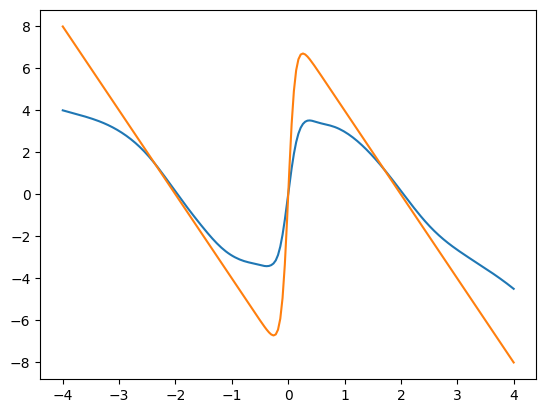

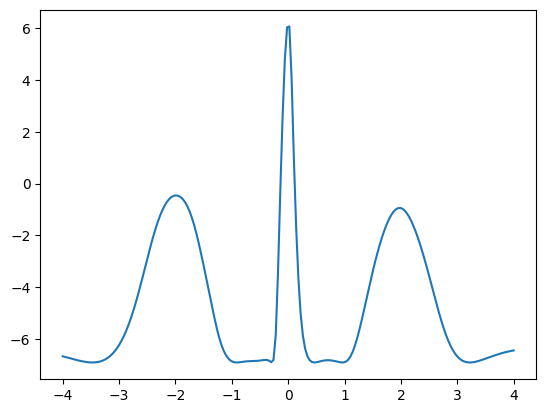

In [96]:


if d == 1:
    x_test = jnp.linspace(-4,4,200)[:,None]
    times_test = jnp.ones((200,))
    y, std = model_fn(params, times_test, x_test)
    y_true = target_score(x_test)
    plt.plot(x_test, y)
    plt.plot(x_test, y_true)
    plt.show()
    plt.plot(x_test, std)
    plt.show()
else:
    samples_test = sample(key, 1000)
    y, _ = model_fn(params, times, samples_test)
    y_true = target_score(samples_test)
    loss = jnp.mean((y - y_true)**2)
    print(loss)


In [97]:
_f = lambda x: model_fn(params, times, x)[0]
_f_ture = lambda x: target_score(x)
jac = jax.vmap(jax.jacobian(_f))(x_test)
jac_true = jax.vmap(jax.jacobian(_f_ture))(x_test)

In [98]:
jac.shape

(200, 1, 1)

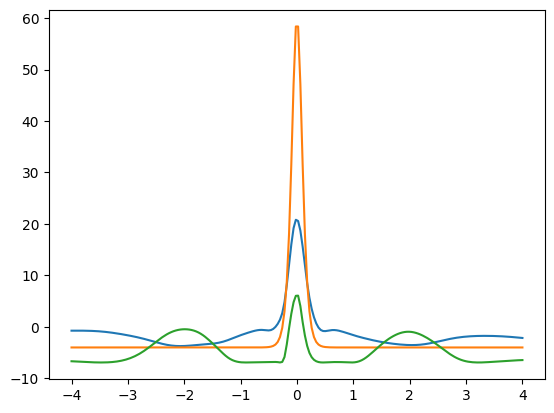

In [99]:
plt.plot(x_test, jac[:,0,0])
plt.plot(x_test, jac_true[:,0,0])
plt.plot(x_test, std)